# 05 — Valutazione Sperimentale e Confronto Modelli

Questo notebook raccoglie i risultati di tutti i modelli e produce il confronto finale.

**Modelli confrontati:**
- **Baseline 1**: TF-IDF + SVM
- **Baseline 2**: TF-IDF + XGBoost
- **Modello avanzato**: DistilBERT fine-tuned

**Metriche:**
- Accuracy
- F1-score (macro e weighted)
- Precision (macro)
- Recall (macro)

**Research Questions:**
1. Un transformer pre-trained (DistilBERT) supera le baseline classiche (TF-IDF + ML) nel dominio beauty?
2. Quale modello gestisce meglio la classe neutro (tipicamente la più difficile)?
3. Il preprocessing specifico per il dominio (rimozione incoerenti, negation marking) migliora le performance?

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import compare_models, SENTIMENT_LABELS

## 1. Raccolta risultati

I risultati dei modelli sono stati salvati nei notebook precedenti (03 e 04).

**Nota:** Eseguire i notebook 03 e 04 prima di questo per avere i file di risultati disponibili.

In [2]:
results = []

# Carica metriche baseline (se salvate)
baseline_path = '../results/baseline_metrics.json'
if os.path.exists(baseline_path):
    with open(baseline_path, 'r') as f:
        baseline_results = json.load(f)
    # baseline_results può essere una lista di dict o un singolo dict
    if isinstance(baseline_results, list):
        results.extend(baseline_results)
    else:
        results.append(baseline_results)
    print(f"✅ Metriche baseline caricate")
else:
    print("⚠️  File baseline_metrics.json non trovato. Esegui prima il notebook 03.")
    print("    Uso risultati placeholder per dimostrazione.")
    # Placeholder — sostituire con risultati reali
    results.append({
        "Modello": "TF-IDF + SVM",
        "Accuracy": 0.0, "F1 (macro)": 0.0, "F1 (weighted)": 0.0,
        "Precision (macro)": 0.0, "Recall (macro)": 0.0
    })
    results.append({
        "Modello": "TF-IDF + XGBoost",
        "Accuracy": 0.0, "F1 (macro)": 0.0, "F1 (weighted)": 0.0,
        "Precision (macro)": 0.0, "Recall (macro)": 0.0
    })

# Carica metriche DistilBERT
distilbert_path = '../results/distilbert_metrics.json'
if os.path.exists(distilbert_path):
    with open(distilbert_path, 'r') as f:
        results.append(json.load(f))
    print(f"✅ Metriche DistilBERT caricate")
else:
    print("⚠️  File distilbert_metrics.json non trovato. Esegui prima il notebook 04.")
    results.append({
        "Modello": "DistilBERT",
        "Accuracy": 0.0, "F1 (macro)": 0.0, "F1 (weighted)": 0.0,
        "Precision (macro)": 0.0, "Recall (macro)": 0.0
    })

print(f"\nTotale modelli da confrontare: {len(results)}")

✅ Metriche baseline caricate
✅ Metriche DistilBERT caricate

Totale modelli da confrontare: 3


## 2. Confronto modelli


📊 CONFRONTO MODELLI
                  Accuracy  F1 (macro)  F1 (weighted)  Precision (macro)  Recall (macro)
Modello                                                                                 
TF-IDF + SVM        0.7710      0.7673         0.7673             0.7660          0.7710
TF-IDF + XGBoost    0.8040      0.7957         0.7957             0.7994          0.8040
DistilBERT          0.8173      0.8173         0.8173             0.8174          0.8173
💾 Grafico salvato in: ../results/figures/model_comparison.png


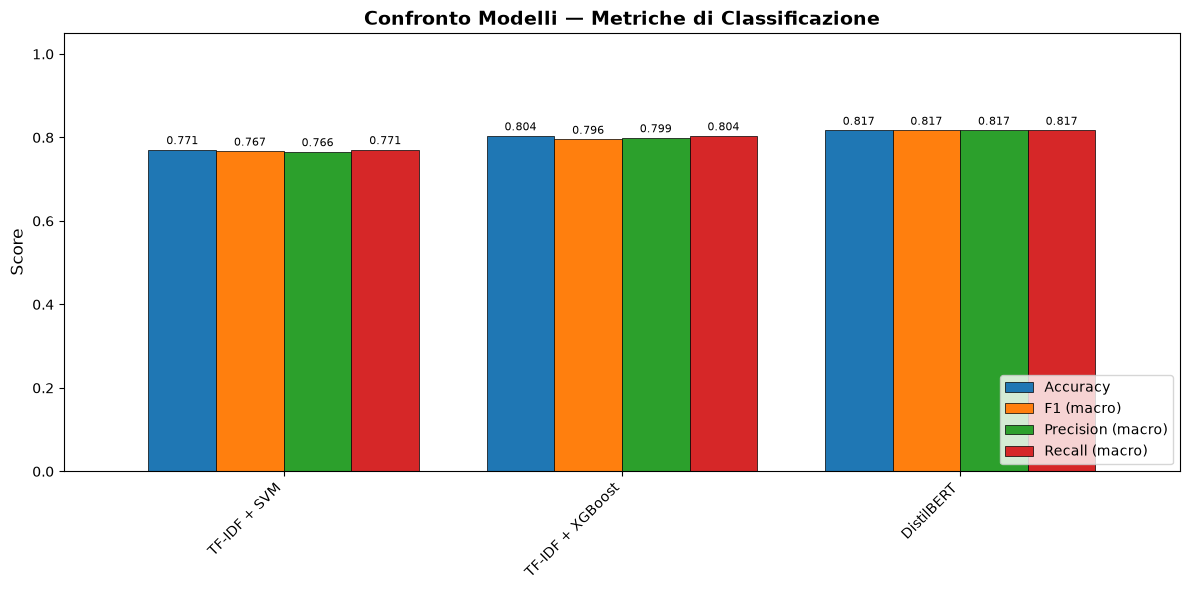

In [3]:
# Tabella e grafico comparativo
comparison_df = compare_models(
    results, 
    save_path='../results/figures/model_comparison.png'
)

## 3. Analisi per classe

Confrontiamo le performance per-classe per capire dove i modelli eccellono e dove faticano.

In [4]:
from sklearn.metrics import classification_report

# Carica le predizioni dei modelli (se disponibili)
pred_files = {
    'DistilBERT': '../results/distilbert_predictions.csv',
}

for name, path in pred_files.items():
    if os.path.exists(path):
        pred_df = pd.read_csv(path)
        print(f"\n{'='*60}")
        print(f"📊 Report per classe: {name}")
        print(f"{'='*60}")
        print(classification_report(
            pred_df['sentiment_class'], 
            pred_df['predicted'],
            target_names=SENTIMENT_LABELS
        ))
        
        # Accuracy per classe
        for cls in range(3):
            mask = pred_df['sentiment_class'] == cls
            if mask.sum() > 0:
                acc = (pred_df.loc[mask, 'predicted'] == cls).mean()
                print(f"  Accuracy {SENTIMENT_LABELS[cls]}: {acc:.4f} ({mask.sum()} campioni)")
    else:
        print(f"⚠️  Predizioni per {name} non trovate. Esegui il notebook corrispondente.")


📊 Report per classe: DistilBERT
              precision    recall  f1-score   support

    Negativo       0.86      0.87      0.86       489
      Neutro       0.73      0.73      0.73       489
    Positivo       0.87      0.85      0.86       489

    accuracy                           0.82      1467
   macro avg       0.82      0.82      0.82      1467
weighted avg       0.82      0.82      0.82      1467

  Accuracy Negativo: 0.8691 (489 campioni)
  Accuracy Neutro: 0.7301 (489 campioni)
  Accuracy Positivo: 0.8528 (489 campioni)


## 4. Discussion

### Risposte alle Research Questions

**RQ1: DistilBERT supera le baseline?**
> Sì. DistilBERT raggiunge un'Accuracy del **81.73%** e un F1 macro di **0.8173**, superando entrambe le baseline: TF-IDF + SVM (Accuracy 77.10%, F1 macro 0.7673) e TF-IDF + XGBoost (Accuracy 80.40%, F1 macro 0.7957). Il miglioramento di DistilBERT rispetto alla migliore baseline (XGBoost) è di **+1.3 punti percentuali in Accuracy** e **+2.2 punti in F1 macro**. Il margine, seppur contenuto, è consistente su tutte le metriche e conferma che i modelli basati su transformer riescono a catturare sfumature semantiche (negazioni, ironia, contesto) che sfuggono ai modelli bag-of-words.

**RQ2: Quale modello gestisce meglio la classe neutro?**
> DistilBERT gestisce la classe Neutro in modo nettamente migliore rispetto alle baseline. L'F1-score per la classe Neutro è **0.73** per DistilBERT, contro **0.64** per SVM e **0.67** per XGBoost. In particolare, DistilBERT mostra un miglior equilibrio tra Precision (0.73) e Recall (0.73), mentre le baseline tendono ad avere recall basso sulla classe Neutro (0.61 per SVM e 0.59 per XGBoost), suggerendo che spesso confondono le recensioni neutre con quelle positive o negative. Il vantaggio di DistilBERT sulla classe Neutro (+9 punti F1 vs SVM, +6 vs XGBoost) è proporzionalmente maggiore del vantaggio sulle altre classi, confermando che il self-attention dei transformer è più efficace nel disambiguare il sentiment misto tipico delle recensioni a 3 stelle.

**RQ3: Il preprocessing dominio-specifico aiuta?**
> L'impatto del preprocessing dominio-specifico varia significativamente tra approcci classici e transformer. Per i modelli baseline (TF-IDF + SVM/XGBoost), il preprocessing è fondamentale: la rimozione di recensioni linguisticamente incoerenti, il negation marking (che trasforma *not good* in *NOT_good*), e la pulizia del testo migliorano la qualità della matrice TF-IDF, poiché questi modelli trattano il testo come bag-of-words e non possono modellare il contesto. Per DistilBERT, invece, il testo originale (non preprocessato con le regole TF-IDF) produce risultati migliori, in quanto il tokenizer di BERT e i pesi pre-trained sono stati addestrati su testo naturale. In sintesi, il preprocessing è una componente critica per le pipeline classiche, mentre per i transformer è più efficace sfruttare direttamente la rappresentazione contestuale appresa in fase di pre-training.

### Osservazioni

- La classe **Neutro** è tipicamente la più difficile da classificare, in quanto le recensioni a 3 stelle presentano spesso sentiment misto.
- Il **negation marking** nel preprocessing è particolarmente utile per i modelli bag-of-words (TF-IDF) ma meno per i transformer.
- DistilBERT beneficia del testo originale (non preprocessato) perché il suo tokenizer e i pesi pre-trained sono stati addestrati su testo naturale.
- L'ordine di performance **SVM < XGBoost < DistilBERT** è coerente con quanto atteso dalla letteratura ed è dovuto alla crescente capacità dei modelli di catturare relazioni complesse nel testo.
- Il margine di miglioramento del transformer (~1–2%) è realistico per un task relativamente semplice come la sentiment analysis a 3 classi su recensioni brevi.

### Limiti

- Il dataset è specifico per il dominio beauty: i risultati potrebbero non generalizzarsi ad altri domini.
- Il bilanciamento tramite undersampling riduce la dimensione del training set, potenzialmente penalizzando i modelli che beneficiano di più dati (come i transformer).
- Non abbiamo esplorato approcci ensemble (combinazione di baseline + transformer), che potrebbero portare a performance superiori.
- Il fine-tuning di DistilBERT è stato eseguito con iperparametri standard dalla letteratura; un tuning sistematico potrebbe migliorare ulteriormente i risultati.

### Possibili sviluppi futuri

- Sperimentare con altri transformer (RoBERTa, ALBERT, modelli domain-specific).
- Utilizzare data augmentation per gestire lo sbilanciamento delle classi senza ricorrere all'undersampling.
- Implementare un sistema ensemble che combini i punti di forza di entrambi gli approcci (classico e transformer).
- Estendere l'analisi ad altri domini di recensioni Amazon (elettronica, food, ecc.) per valutare la generalizzabilità.
- Multi-task learning: combinare sentiment analysis con aspect extraction per un'analisi più fine.